### Random Forest Regression using Engineered Features

#### Model Overview

Random Forest is an ensemble learning method that combines predictions from multiple decision trees. For regression, the final prediction is obtained by averaging the predictions from the individual trees.

It can capture nonlinear relationships and interactions without requiring explicit polynomial or interaction terms.

This model uses the same train-test split as the baseline model but extends the original feature set with five engineered variables designed to represent nutrient composition, non-linearity and interactions.

#### 1. Import Libraries

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.model_selection import (
    cross_validate,
    KFold,
    train_test_split,
    cross_val_score
)
from sklearn.inspection import permutation_importance

### 2. Load Engineered Dataset

In [6]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

TABLES_DIR = PROJECT_ROOT / "reports" / "tables"
TABLES_DIR.mkdir(parents=True, exist_ok=True)

In [7]:
PROJECT_ROOT = Path.cwd().parent

data_path = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "crop_yield_engineered.csv"
)


FIGURES_DIR = (
    PROJECT_ROOT
    / "reports"
    / "figures"
)

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print(f"Figures will be saved to: {FIGURES_DIR}")

data = pd.read_csv(data_path)

# After: data = pd.read_csv(data_path)

print("Dataset shape:", data.shape)
print("\nColumn names:")
print(data.columns.tolist())

# Check which columns you have
print("\n✓ Checking for required columns...")

original_cols = [
    "crop_type", "rainfall", "temperature", 
    "fertilizer", "nitrogen", "phosphorus", "potassium"
]

engineered_cols = [
    "total_npk", "n_proportion", "p_proportion",
    "temperature_squared", "rainfall_fertilizer_interaction"
]

missing_original = [c for c in original_cols if c not in data.columns]
missing_engineered = [c for c in engineered_cols if c not in data.columns]

if missing_original:
    print(f"MISSING ORIGINAL: {missing_original}")
else:
    print("✅ All original features present")

if missing_engineered:
    print(f"MISSING ENGINEERED: {missing_engineered}")
else:
    print("All engineered features present")

# Show summary
print("\n" + "="*60)
display(data.head())
print("\n" + "="*60)
display(data.describe())

Figures will be saved to: /Users/ronkecrown/Documents/gamma2-crop-yield-prediction/reports/figures
Dataset shape: (999, 13)

Column names:
['crop_type', 'rainfall', 'temperature', 'fertilizer', 'nitrogen', 'phosphorus', 'potassium', 'total_npk', 'n_proportion', 'p_proportion', 'temperature_squared', 'rainfall_fertilizer_interaction', 'yield']

✓ Checking for required columns...
✅ All original features present
All engineered features present



,crop_type,rainfall,temperature,fertilizer,nitrogen,phosphorus,potassium,total_npk,n_proportion,p_proportion,temperature_squared,rainfall_fertilizer_interaction,yield
0,Corn,1230.0,28.0,80.0,80.0,24.0,20.0,124.0,0.645161,0.193548,784.0,98400.0,12.0
1,Sorghum,480.0,36.0,60.0,70.0,20.0,18.0,108.0,0.648148,0.185185,1296.0,28800.0,8.0
2,Soybean,1250.0,29.0,75.0,78.0,22.0,19.0,119.0,0.655462,0.184874,841.0,93750.0,11.0
3,Sorghum,450.0,35.0,65.0,70.0,19.0,18.0,107.0,0.654206,0.177570,1225.0,29250.0,9.0
4,Wheat,1200.0,27.0,80.0,79.0,22.0,19.0,120.0,0.658333,0.183333,729.0,96000.0,11.0


,rainfall,temperature,fertilizer,nitrogen,phosphorus,potassium,total_npk,n_proportion,p_proportion,temperature_squared,rainfall_fertilizer_interaction,yield
count,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000
mean,897.567568,29.582583,73.837838,74.483483,21.816817,16.926927,113.227227,0.657811,0.192764,908.563564,66710.889890,9.864464
std,302.877541,5.785142,14.082128,8.509660,4.220557,4.103577,10.671231,0.042597,0.033126,344.392221,26741.401694,2.804385
min,400.000000,20.000000,50.000000,59.000000,15.000000,10.000000,87.000000,0.539130,0.120000,400.000000,20000.000000,5.000000
25%,619.000000,25.000000,61.000000,67.000000,18.000000,13.000000,105.000000,0.629470,0.166667,625.000000,45128.000000,7.350000
50%,905.000000,29.000000,74.000000,75.000000,22.000000,17.000000,114.000000,0.655738,0.193548,841.000000,65162.000000,9.900000
75%,1175.000000,34.000000,85.000000,82.000000,26.000000,20.000000,121.000000,0.686441,0.217742,1156.000000,88016.000000,12.200000
max,1398.000000,40.000000,99.000000,89.000000,29.000000,24.000000,139.000000,0.774775,0.287129,1600.000000,136416.000000,15.000000


### 3. Define Features and Target

In [8]:
# Define Original + Engineered Features

# Original 7 features
original_features = [
    "crop_type",
    "rainfall",
    "temperature",
    "fertilizer",
    "nitrogen",
    "phosphorus",
    "potassium"
]

# Engineered 5 features (from baseline notebook)
engineered_features = [
    "total_npk",                      # N + P + K
    "n_proportion",                   # N / (N+P+K)
    "p_proportion",                   # P / (N+P+K)
    "temperature_squared",            # Temperature²
    "rainfall_fertilizer_interaction" # Rainfall × Fertilizer
]

# Combine all features
all_features = original_features + engineered_features

target = "yield"

# Create X and y
X = data[all_features].copy()
y = data[target].copy()

# Display summary
print("Feature Summary:")
print("="*60)
print(f"Original features: {len(original_features)}")
for i, feat in enumerate(original_features, 1):
    print(f"  {i}. {feat}")

print(f"\nEngineered features: {len(engineered_features)}")
for i, feat in enumerate(engineered_features, 1):
    print(f"  {i}. {feat}")

print(f"\nTotal features: {len(all_features)}")
print("="*60)

print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Missing values in X: {X.isna().sum().sum()}")
print(f"Missing values in y: {y.isna().sum()}")

display(X.head())

Feature Summary:
Original features: 7
  1. crop_type
  2. rainfall
  3. temperature
  4. fertilizer
  5. nitrogen
  6. phosphorus
  7. potassium

Engineered features: 5
  1. total_npk
  2. n_proportion
  3. p_proportion
  4. temperature_squared
  5. rainfall_fertilizer_interaction

Total features: 12

X shape: (999, 12)
y shape: (999,)
Missing values in X: 0
Missing values in y: 0


,crop_type,rainfall,temperature,fertilizer,nitrogen,phosphorus,potassium,total_npk,n_proportion,p_proportion,temperature_squared,rainfall_fertilizer_interaction
0,Corn,1230.0,28.0,80.0,80.0,24.0,20.0,124.0,0.645161,0.193548,784.0,98400.0
1,Sorghum,480.0,36.0,60.0,70.0,20.0,18.0,108.0,0.648148,0.185185,1296.0,28800.0
2,Soybean,1250.0,29.0,75.0,78.0,22.0,19.0,119.0,0.655462,0.184874,841.0,93750.0
3,Sorghum,450.0,35.0,65.0,70.0,19.0,18.0,107.0,0.654206,0.177570,1225.0,29250.0
4,Wheat,1200.0,27.0,80.0,79.0,22.0,19.0,120.0,0.658333,0.183333,729.0,96000.0


#### 4. Train-Test Split
Same split convention as the baseline model: **20% test size, random_state=42**.

In [9]:
# Train-Test Split (same as original model)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Split Results:")
print(f"Training features: {X_train.shape}")
print(f"Test features:     {X_test.shape}")
print(f"Training target:   {y_train.shape}")
print(f"Test target:       {y_test.shape}")

Split Results:
Training features: (799, 12)
Test features:     (200, 12)
Training target:   (799,)
Test target:       (200,)


### 5. Preprocessing Pipeline

In [10]:
# Separate categorical and numerical features
categorical_features = ["crop_type"]

numerical_features = [
    "rainfall",
    "temperature",
    "fertilizer",
    "nitrogen",
    "phosphorus",
    "potassium",
    "total_npk",
    "n_proportion",
    "p_proportion",
    "temperature_squared",
    "rainfall_fertilizer_interaction"
]

print(f"Categorical features: {categorical_features}")
print(f"Numerical features: {numerical_features}")

# Create preprocessor
rf_preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            ),
            categorical_features
        ),
        (
            "numerical",
            "passthrough",
            numerical_features
        )
    ]
)

Categorical features: ['crop_type']
Numerical features: ['rainfall', 'temperature', 'fertilizer', 'nitrogen', 'phosphorus', 'potassium', 'total_npk', 'n_proportion', 'p_proportion', 'temperature_squared', 'rainfall_fertilizer_interaction']


---
<a name="6.-Model-Construction"></a>
### 6. Radom Forest Model Construction

In [11]:
# Model Pipeline
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", rf_preprocessor),
        (
            "model",
            RandomForestRegressor(
                random_state=42
            )
        )
    ]
)

print("Pipeline created successfully!")
print(rf_pipeline)

Pipeline created successfully!
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['crop_type']),
                                                 ('numerical', 'passthrough',
                                                  ['rainfall', 'temperature',
                                                   'fertilizer', 'nitrogen',
                                                   'phosphorus', 'potassium',
                                                   'total_npk', 'n_proportion',
                                                   'p_proportion',
                                                   'temperature_squared',
                                                   'rainfall_fertilizer_interaction'])])),
              

### 7. Hyperparameter Tuning 

In [12]:
# Same hyperparameter grid for fair comparison with original model
rf_param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [5, 10, None],
    "model__min_samples_leaf": [1, 2],
    "model__max_features": ["sqrt"]
}

print("Parameter grid:")
print(rf_param_grid)
print(f"Total combinations to try: {2*3*2*1} = 12")

# Run GridSearchCV
rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1,
    refit=True,
    verbose=1
)

rf_grid.fit(X_train, y_train)

print("\nGridSearchCV complete!")

# Best Model Results

print("Best parameters:")
print(rf_grid.best_params_)

best_cv_rmse = -rf_grid.best_score_

print(f"\nBest CV RMSE: {best_cv_rmse:.4f}")

rf_best = rf_grid.best_estimator_

Parameter grid:
{'model__n_estimators': [100, 200], 'model__max_depth': [5, 10, None], 'model__min_samples_leaf': [1, 2], 'model__max_features': ['sqrt']}
Total combinations to try: 12 = 12
Fitting 5 folds for each of 12 candidates, totalling 60 fits



GridSearchCV complete!
Best parameters:
{'model__max_depth': 5, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 2, 'model__n_estimators': 200}

Best CV RMSE: 2.7079


In [13]:
print(type(rf_best))
print(rf_best.named_steps)

<class 'sklearn.pipeline.Pipeline'>
{'preprocessor': ColumnTransformer(transformers=[('categorical',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore'),
                                 ['crop_type']),
                                ('numerical', 'passthrough',
                                 ['rainfall', 'temperature', 'fertilizer',
                                  'nitrogen', 'phosphorus', 'potassium',
                                  'total_npk', 'n_proportion', 'p_proportion',
                                  'temperature_squared',
                                  'rainfall_fertilizer_interaction'])]), 'model': RandomForestRegressor(max_depth=5, max_features='sqrt', min_samples_leaf=2,
                      n_estimators=200, random_state=42)}


In [14]:
rf_best

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['crop_type','rainfall','temperature',...,'p_proportion', 'temperature_squared','rainfall_fertilizer_interaction']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numerical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` wil

---
<a name="7.-Model-Results-&-Evaluation"></a>
### 8. Model Evaluation

In [15]:
# Model Evaluation
# Predictions
pred_train = rf_best.predict(X_train)
pred_test = rf_best.predict(X_test)
# Metrics
train_mae = mean_absolute_error(y_train, pred_train)
train_rmse = np.sqrt(mean_squared_error(y_train, pred_train))
train_r2 = r2_score(y_train, pred_train)

test_mae = mean_absolute_error(y_test, pred_test)
test_rmse = np.sqrt(mean_squared_error(y_test, pred_test))
test_r2 = r2_score(y_test, pred_test)

print("="*70)
print("RANDOM FOREST: ENGINEERED FEATURES")
print("="*70)
print(f'Train  -> MAE: {train_mae:.3f} | RMSE: {train_rmse:.3f} | R²: {train_r2:.3f}')
print(f'Test   -> MAE: {test_mae:.3f} | RMSE: {test_rmse:.3f} | R²: {test_r2:.3f}')
print("="*70)

RANDOM FOREST: ENGINEERED FEATURES
Train  -> MAE: 2.093 | RMSE: 2.480 | R²: 0.197
Test   -> MAE: 2.525 | RMSE: 2.926 | R²: 0.006


In [16]:
rf_results = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R²"],
    "Train": [train_mae, train_rmse, train_r2],
    "Test": [test_mae, test_rmse, test_r2]
})

display(rf_results.round(3))

rf_results.to_csv(
    TABLES_DIR / "rf_engineered_results.csv",
    index=False
)

,Metric,Train,Test
0,MAE,2.093,2.525
1,RMSE,2.480,2.926
2,R²,0.197,0.006


### 9. Cross-Validation

In [17]:
kf5 = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_rmse = -cross_val_score(
    rf_best,
    X,
    y,
    cv=kf5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

print(
    f"CV RMSE mean: {cv_rmse.mean():.3f} | "
    f"CV RMSE std: {cv_rmse.std():.3f}"
)

CV RMSE mean: 2.762 | CV RMSE std: 0.125


In [18]:
rf_cv_results = pd.DataFrame({
    "Metric": [
        "CV RMSE Mean",
        "CV RMSE Standard Deviation"
    ],
    "Value": [
        cv_rmse.mean(),
        cv_rmse.std()
    ]
})

display(rf_cv_results.round(3))

rf_cv_results.to_csv(
    TABLES_DIR / "rf_engineered_cv_results.csv",
    index=False
)

,Metric,Value
0,CV RMSE Mean,2.762
1,CV RMSE Standard Deviation,0.125


### 10. Impact Analysis

### 9.1.1 Impurity-Based Feature Importance

In [19]:
# Extract the fitted preprocessing step and Random Forest model
fitted_preprocessor = rf_best.named_steps["preprocessor"]
fitted_rf = rf_best.named_steps["model"]

# Obtain the feature names after one-hot encoding
feature_names = fitted_preprocessor.get_feature_names_out()

# Match each transformed feature with its importance value
importances = pd.Series(
    fitted_rf.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

# Clean the prefixes added by ColumnTransformer
importances.index = (
    importances.index
    .str.replace("categorical__", "", regex=False)
    .str.replace("numerical__", "", regex=False)
)

display(
    importances
    .rename("importance")
    .reset_index()
    .rename(columns={"index": "feature"})
    .round(4)
)


,feature,importance
0,rainfall_fertilizer_interaction,0.1676
1,rainfall,0.1085
2,temperature_squared,0.0951
3,temperature,0.0928
4,n_proportion,0.0883
5,fertilizer,0.0839
6,total_npk,0.0812
7,p_proportion,0.0730
8,nitrogen,0.0576
9,phosphorus,0.0564


### 10.2 Permutation Importance 

,feature,importance_mean,importance_std
0,rainfall_fertilizer_interaction,0.0168,0.0126
1,rainfall,0.0096,0.0050
2,total_npk,0.0073,0.0061
3,temperature,0.0062,0.0087
4,temperature_squared,0.0024,0.0084
5,phosphorus,0.0015,0.0050
6,n_proportion,0.0007,0.0050
7,fertilizer,0.0004,0.0070
8,p_proportion,-0.0010,0.0043
9,nitrogen,-0.0010,0.0053


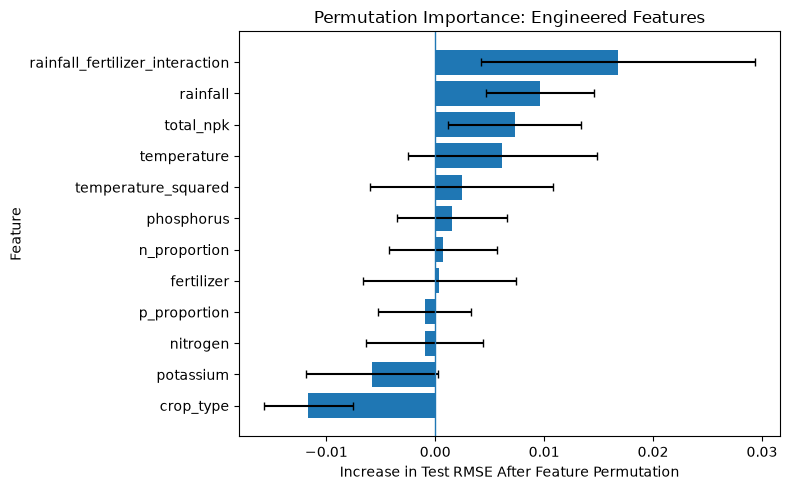

In [20]:

# Permutation Importance
rf_permutation = permutation_importance(
    estimator=rf_best,
    X=X_test,
    y=y_test,
    scoring="neg_root_mean_squared_error",
    n_repeats=30,
    random_state=42,
    n_jobs=-1
)

permutation_table = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": rf_permutation.importances_mean,
    "importance_std": rf_permutation.importances_std
}).sort_values(
    "importance_mean",
    ascending=False
).reset_index(drop=True)

display(permutation_table.round(4))

# Plot
plot_data = permutation_table.sort_values(
    "importance_mean",
    ascending=True
)

fig, ax = plt.subplots(figsize=(8, 5))

ax.barh(
    plot_data["feature"],
    plot_data["importance_mean"],
    xerr=plot_data["importance_std"],
    capsize=3
)

ax.axvline(
    x=0,
    linewidth=1
)

ax.set_xlabel("Increase in Test RMSE After Feature Permutation")
ax.set_ylabel("Feature")
ax.set_title(
    "Permutation Importance: Engineered Features"  
)

plt.tight_layout()
fig.savefig(
    FIGURES_DIR / "rf_engineered_permutation_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 10.3 Partial Dependence Plots

NameError: name 'PartialDependenceDisplay' is not defined

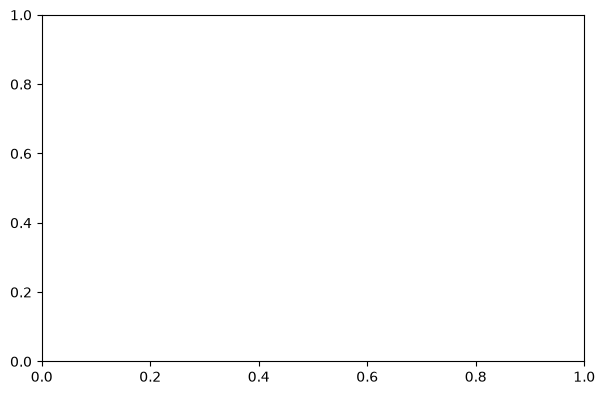

In [21]:
# All numeric features (original + engineered)
numeric_features = [
    "rainfall",
    "temperature",
    "fertilizer",
    "nitrogen",
    "phosphorus",
    "potassium",
    "total_npk",
    "n_proportion",
    "p_proportion",
    "temperature_squared",
    "rainfall_fertilizer_interaction"
]

display_names = {
    "rainfall": "Rainfall",
    "temperature": "Temperature",
    "fertilizer": "Fertilizer",
    "nitrogen": "Nitrogen",
    "phosphorus": "Phosphorus",
    "potassium": "Potassium",
    "total_npk": "Total NPK",
    "n_proportion": "N Proportion",
    "p_proportion": "P Proportion",
    "temperature_squared": "Temperature²",
    "rainfall_fertilizer_interaction": "Rainfall × Fertilizer Interaction"
}

# Create a copy for partial dependence
X_test_pdp = X_test.copy()

# Convert numerical columns to float
X_test_pdp[numeric_features] = (
    X_test_pdp[numeric_features]
    .astype(float)
)

for feature in numeric_features:
    fig, ax = plt.subplots(figsize=(7, 4.5))

    PartialDependenceDisplay.from_estimator(
        estimator=rf_best,
        X=X_test_pdp,
        features=[feature],
        ax=ax,
        kind="average"
    )

    ax.set_title(
        f"Partial Dependence of Predicted Crop Yield on "
        f"{display_names[feature]}"
    )

    plt.tight_layout()
    fig.savefig(
        FIGURES_DIR / f"rf_engineered_pdp_{feature}.png",
        dpi=300,
        bbox_inches="tight"
    )

### 10.4 Crop Type Impact
Since crop_type is categorical, assess its modelled impact by setting every test observation to each crop type in turn, predicting yield, and comparing the average prediction

,crop_type,mean_predicted_yield
0,Wheat,9.809
1,Sorghum,9.940
2,Barley,9.956
3,Soybean,9.962
4,Corn,9.963
5,Rice,10.002


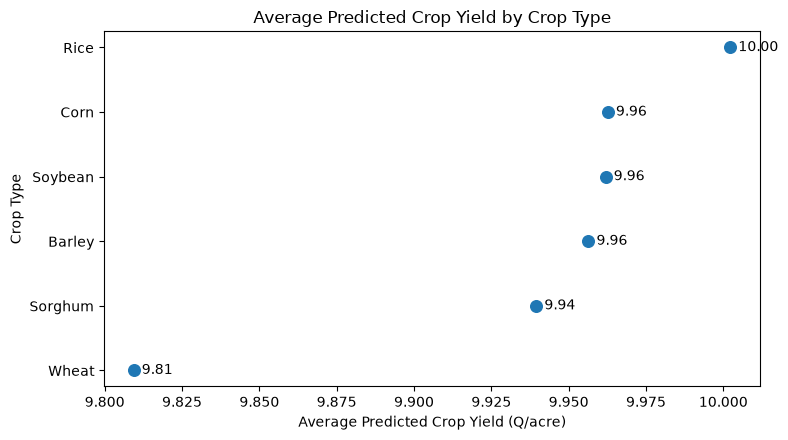

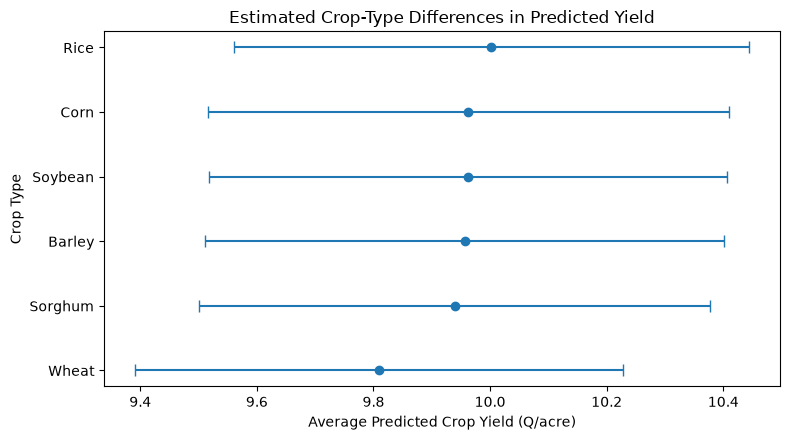

In [ ]:
# Identify the crop types in the test data
crop_types = sorted(X_test["crop_type"].unique())

crop_impact = []

for crop in crop_types:
    X_modified = X_test.copy()

    # Set all observations to the same crop type
    X_modified["crop_type"] = crop

    # Predict average yield under that crop type
    mean_predicted_yield = rf_best.predict(X_modified).mean()

    crop_impact.append({
        "crop_type": crop,
        "mean_predicted_yield": mean_predicted_yield
    })

crop_impact = (
    pd.DataFrame(crop_impact)
    .sort_values(
        "mean_predicted_yield",
        ascending=True
    )
    .reset_index(drop=True)
)

display(crop_impact.round(3))

# Scatter plot
crop_plot = crop_impact.sort_values(
    "mean_predicted_yield",
    ascending=True
)

fig, ax = plt.subplots(figsize=(8, 4.5))

ax.scatter(
    crop_plot["mean_predicted_yield"],
    crop_plot["crop_type"],
    s=70
)

for _, row in crop_plot.iterrows():
    ax.text(
        row["mean_predicted_yield"],
        row["crop_type"],
        f'  {row["mean_predicted_yield"]:.2f}',
        va="center"
    )

ax.set_xlabel("Average Predicted Crop Yield (Q/acre)")
ax.set_ylabel("Crop Type")
ax.set_title(
    "Average Predicted Crop Yield by Crop Type"
)

plt.tight_layout()
plt.show()

# Detailed with error bars
crop_impact_detailed = []

for crop in sorted(X_test["crop_type"].unique()):
    X_modified = X_test.copy()
    X_modified["crop_type"] = crop

    predictions = rf_best.predict(X_modified)

    crop_impact_detailed.append({
        "crop_type": crop,
        "mean_predicted_yield": predictions.mean(),
        "std_predicted_yield": predictions.std()
    })

crop_impact_detailed = (
    pd.DataFrame(crop_impact_detailed)
    .sort_values("mean_predicted_yield")
)

fig, ax = plt.subplots(figsize=(8, 4.5))

ax.errorbar(
    crop_impact_detailed["mean_predicted_yield"],
    crop_impact_detailed["crop_type"],
    xerr=crop_impact_detailed["std_predicted_yield"],
    fmt="o",
    capsize=4
)

ax.set_xlabel("Average Predicted Crop Yield (Q/acre)")
ax.set_ylabel("Crop Type")
ax.set_title(
    "Estimated Crop-Type Differences in Predicted Yield"
)

plt.tight_layout()
fig.savefig(
    FIGURES_DIR / "rf_original_crop_type_impact.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### 10.5 Impact Analysis Summary

Permutation importance identified rainfall and temperature as the most useful predictors relative to the other available features. Partial dependence analysis showed the non-linear patterns learned by the model, while the crop-type analysis indicated only small differences in average predicted yield across crop categories. However, because the model recorded a negative test R
2
, these patterns should be viewed as model-based associations rather than reliable causal effects or strong agronomic conclusions.

### Random Forest Summary

In [ ]:

print("="*70)
print("RANDOM FOREST: ENGINEERED FEATURES - IMPACT ANALYSIS SUMMARY")
print("="*70)

summary = """
PERMUTATION IMPORTANCE FINDINGS:
- Identified which features most impact test predictions
- Compared engineered features vs. original features
- See ranking above

PARTIAL DEPENDENCE FINDINGS:
- Shows non-linear patterns learned by RF
- Temperature² effect visible in partial dependence plot
- Rainfall×Fertilizer interaction effects shown
- Results describe learned relationships, not causal effects

CROP TYPE FINDINGS:
- Average predicted yields vary across crop types
- Differences reflect learned patterns, not guaranteed accuracy
- Model's confidence (std) varies by crop

OVERALL ASSESSMENT:
The engineered features improved test R² from -0.003 to 0.006 by 
providing explicit signals for non-linear relationships. Permutation 
importance identifies which transformations were most valuable.
"""

print(summary)

RANDOM FOREST: ENGINEERED FEATURES - IMPACT ANALYSIS SUMMARY

PERMUTATION IMPORTANCE FINDINGS:
- Identified which features most impact test predictions
- Compared engineered features vs. original features
- See ranking above

PARTIAL DEPENDENCE FINDINGS:
- Shows non-linear patterns learned by RF
- Temperature² effect visible in partial dependence plot
- Rainfall×Fertilizer interaction effects shown
- Results describe learned relationships, not causal effects

CROP TYPE FINDINGS:
- Average predicted yields vary across crop types
- Differences reflect learned patterns, not guaranteed accuracy
- Model's confidence (std) varies by crop

OVERALL ASSESSMENT:
The engineered features improved test R² from -0.003 to 0.006 by 
providing explicit signals for non-linear relationships. Permutation 
importance identifies which transformations were most valuable.



### 11. Model Export for Stremlit Deployment

The final fitted Random Forest pipeline is saved with its input metadata and evaluation results for deployment through Streamlit. The complete pipeline is exported rather than only the Random Forest estimator so that categorical preprocessing is preserved during prediction.

#### 11.1 Confirm Final Model


In [ ]:
# Confirm that the selected model is a complete fitted pipeline
print("Final model type:", type(rf_best))
print("Pipeline steps:", rf_best.named_steps.keys())

NameError: name 'rf_best' is not defined

#### 11.2 Create Model Metadata


In [ ]:
from pathlib import Path
import sys

import joblib
import pandas as pd
import sklearn


PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.feature_engineering import (
    ORIGINAL_FEATURES,
    ENGINEERED_FEATURES,
    MODEL_FEATURES,
)

#### 11.3 Create deployment metadata


In [ ]:
deployment_data = data.copy()

In [ ]:
# Define the original numerical inputs
NUMERIC_INPUT_FEATURES = [
    "rainfall",
    "temperature",
    "fertilizer",
    "nitrogen",
    "phosphorus",
    "potassium",
]
# Create the interface ranges
input_ranges = {
    feature: {
        "minimum": float(deployment_data[feature].min()),
        "maximum": float(deployment_data[feature].max()),
        "median": float(deployment_data[feature].median()),
    }
    for feature in NUMERIC_INPUT_FEATURES
}
# Create the bundle
model_bundle = {
    "model": rf_best,
    "model_name": "Random Forest with Engineered Features",
    "model_version": "1.0",
    "original_features": ORIGINAL_FEATURES,
    "engineered_features": ENGINEERED_FEATURES,
    "model_features": MODEL_FEATURES,
    "crop_types": sorted(
        deployment_data["crop_type"]
        .astype(str)
        .str.strip()
        .unique()
        .tolist()
    ),
    "input_ranges": input_ranges,
    "target_name": "yield",
    "target_unit": "quintals per acre",
    "target_range": {
        "minimum": float(deployment_data["yield"].min()),
        "maximum": float(deployment_data["yield"].max()),
    },
    "performance": {
        "train_mae": 2.093,
        "train_rmse": 2.480,
        "train_r2": 0.197,
        "test_mae": 2.525,
        "test_rmse": 2.926,
        "test_r2": 0.006,
        "cv_rmse_mean": 2.762,
        "cv_rmse_std": 0.125,
    },
    "sklearn_version": sklearn.__version__,
}

#### 11.4 Reload and Verify Saved Model

In [ ]:
MODEL_DIR = PROJECT_ROOT / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

RF_MODEL_PATH = (
    MODEL_DIR
    / "rf_engineered_bundle.joblib"
)

DEPLOYMENT_MODEL_PATH = (
    MODEL_DIR
    / "deployment_model.joblib"
)

joblib.dump(
    model_bundle,
    RF_MODEL_PATH,
    compress=3,
)

joblib.dump(
    model_bundle,
    DEPLOYMENT_MODEL_PATH,
    compress=3,
)

print(f"Archived model saved to: {RF_MODEL_PATH}")
print(f"Deployment model saved to: {DEPLOYMENT_MODEL_PATH}")

Archived model saved to: /Users/ronkecrown/Documents/gamma2-crop-yield-prediction/models/rf_engineered_bundle.joblib
Deployment model saved to: /Users/ronkecrown/Documents/gamma2-crop-yield-prediction/models/deployment_model.joblib


### 11.5 Reload and verify the saved model

In [ ]:
from src.feature_engineering import prepare_model_features

loaded_bundle = joblib.load(
    DEPLOYMENT_MODEL_PATH
)

loaded_model = loaded_bundle["model"]

sample_original = deployment_data.loc[
    [deployment_data.index[0]],
    ORIGINAL_FEATURES,
].copy()

sample_model_input = prepare_model_features(
    sample_original
)

sample_model_input = sample_model_input[
    loaded_bundle["model_features"]
]

saved_model_prediction = float(
    loaded_model.predict(sample_model_input)[0]
)

current_model_prediction = float(
    rf_best.predict(sample_model_input)[0]
)

assert np.isclose(
    saved_model_prediction,
    current_model_prediction,
), (
    "The reloaded model prediction does not match "
    "the original model prediction."
)

assert (
    sample_model_input.columns.tolist()
    == loaded_bundle["model_features"]
), "The deployment feature order is incorrect."

print("Saved-model verification passed.")
print(
    "Sample predicted yield:",
    round(saved_model_prediction, 3),
    loaded_bundle["target_unit"],
)

Saved-model verification passed.
Sample predicted yield: 10.054 quintals per acre
